## Завдання 2 (згорткові нейронні мережі)

---
а) Побудувати просту згорткову нейронну мережу (2–3 convolutional шари + fully connected). Навчіть її на обраному вами датасеті.
б) Використайти попередньо натреновану архітектуру (наприклад, ResNet, VGG, MobileNet). Замінити вихідний класифікатор на новий під ваші класи. Провести донавчання () моделі на вашому датасеті. 

Порівняйти результати (точність, швидкість збіжності, кількость даних).

Для цього було вибрано датасет Rice Image Dataset.

Датасет містить зображення 5 різних видів рису:
Arborio, Basmati, Ipsala, Jasmine, Karacadag

Загалом датасет містить 75,000 зображень (по 15,000 на кожен клас).
https://www.kaggle.com/api/v1/datasets/download/muratkokludataset/rice-image-dataset

Для цього завдання я обрізав датасет до 7,5к зображень (1,5к на кожен клас). Комп'ютер інакше не справлявся(

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import pathlib
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

## Завантаження та розпакування датасету

## Налаштування параметрів

In [8]:
SEED = 42
IMG_SIZE = 250
BATCH = 32

# Structure: Rice_Image_Dataset/Rice_Image_Dataset/Arborio, Basmati, Ipsala, Jasmine, Karacadag
DATA_DIR = pathlib.Path("var_data/Rice_Image_Dataset")

Побудуємо просту CNN архітектуру з 3 згортковими шарами.

Завантаження даних зі структури папок + split train/valid dataset

In [9]:
all_image_paths = []
all_labels = []

# Отримуємо список класів (відсортовано для консистентності)
class_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])
class_names = [d.name for d in class_dirs]
num_classes = len(class_names)

print(f"\n✅ Знайдено {num_classes} класів: {class_names}\n")

# Збираємо шляхи та мітки
for class_idx, class_dir in enumerate(class_dirs):
    # Знаходимо всі зображення у папці класу
    image_files = list(class_dir.glob('*.jpg'))
    
    # Конвертуємо в строки
    image_paths = [str(p) for p in image_files]
    
    all_image_paths.extend(image_paths)
    all_labels.extend([class_idx] * len(image_paths))
    
    print(f"  {class_idx}. {class_names[class_idx]}: {len(image_paths):,} зображень")

print(f"\n✅ Загалом: {len(all_image_paths):,} зображень")

# Стратифіковане розділення (ГАРАНТУЄ рівномірний розподіл класів!)
train_paths, val_paths, train_labels_list, val_labels_list = train_test_split(
    all_image_paths,
    all_labels,
    test_size=0.2,  # 20% для validation
    random_state=SEED,
    stratify=all_labels  # ⬅️ ЦЕ КЛЮЧОВИЙ ПАРАМЕТР!
)

print(f"\n{'='*70}")
print(f"РОЗДІЛЕННЯ ДАНИХ:")
print(f"{'='*70}")
print(f"Train: {len(train_paths):,} зображень ({len(train_paths)/len(all_image_paths)*100:.1f}%)")
print(f"Val:   {len(val_paths):,} зображень ({len(val_paths)/len(all_image_paths)*100:.1f}%)")



✅ Знайдено 5 класів: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

  0. Arborio: 1,500 зображень
  1. Basmati: 1,500 зображень
  2. Ipsala: 1,500 зображень
  3. Jasmine: 1,500 зображень
  4. Karacadag: 1,500 зображень

✅ Загалом: 7,500 зображень

РОЗДІЛЕННЯ ДАНИХ:
Train: 6,000 зображень (80.0%)
Val:   1,500 зображень (20.0%)


In [10]:
# Перевірка розподілу класів
print(f"\n{'='*70}")
print(f"РОЗПОДІЛ КЛАСІВ У VALIDATION (має бути рівномірним):")
print(f"{'='*70}")
for i, name in enumerate(class_names):
    count_val = sum(1 for l in val_labels_list if l == i)
    pct = (count_val / len(val_labels_list)) * 100
    print(f"  {i}. {name:12s}: {count_val:4d} зображень ({pct:5.1f}%)")

# Функція для завантаження та preprocessing зображення
def load_and_preprocess_image(path, label):
    """Завантажує та обробляє зображення"""
    # Читаємо файл
    img = tf.io.read_file(path)
    # Декодуємо (автоматично визначає формат)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    # Встановлюємо shape (необхідно для деяких операцій)
    img.set_shape([None, None, 3])
    # Змінюємо розмір
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    # Конвертуємо в uint8 (0-255)
    img = tf.cast(img, tf.uint8)
    return img, label

# Створюємо TensorFlow датасети
print(f"\n📦 Створення TensorFlow датасетів...")

# Training dataset
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels_list))
train_ds = train_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=1000, seed=SEED)
train_ds = train_ds.batch(BATCH)
train_ds = train_ds.cache()
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# Validation dataset
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels_list))
val_ds = val_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH)
val_ds = val_ds.cache()
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

print(f"✅ Датасети створено!")


РОЗПОДІЛ КЛАСІВ У VALIDATION (має бути рівномірним):
  0. Arborio     :  300 зображень ( 20.0%)
  1. Basmati     :  300 зображень ( 20.0%)
  2. Ipsala      :  300 зображень ( 20.0%)
  3. Jasmine     :  300 зображень ( 20.0%)
  4. Karacadag   :  300 зображень ( 20.0%)

📦 Створення TensorFlow датасетів...
✅ Датасети створено!


In [11]:
print("Classes:", class_names, " | num_classes =", num_classes)

Classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']  | num_classes = 5


### Візуалізація зразків

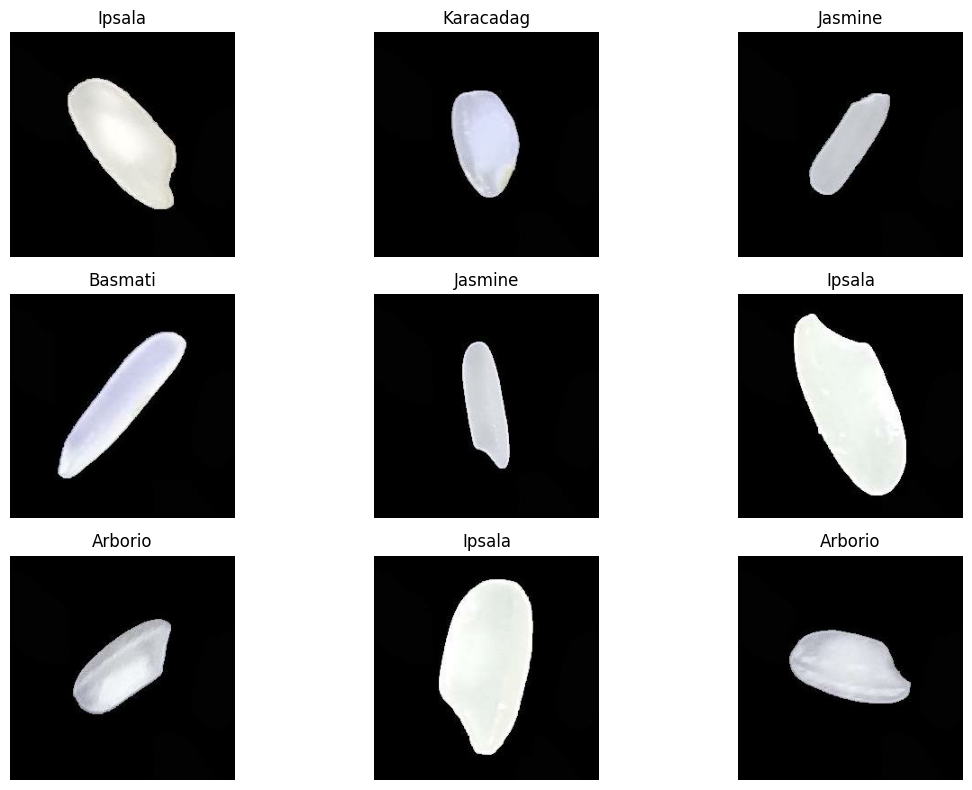

In [12]:
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

Оптимізація завантаження даних (за допомогою гешування)

In [13]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

### Аугментація даних + базова CNN

3 згортки + pooling → Flatten → FC. Dropout проти перенавчання.

In [14]:
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augmentation")

In [15]:
# Побудова моделі
model_simple = models.Sequential([
    
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)), 
    
    # Аугментація
    augment,
    
    # Нормалізація
    layers.Rescaling(1./255),
    
    # Перший згортковий блок
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # Другий згортковий блок
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Третій згортковий блок
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Повнозв'язні шари
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
], name="simple_cnn")

d:\Programing2025\IntelligentDataAnalysis\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Компіляція моделі

In [16]:
model_simple.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_simple.summary()

Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 250, 250, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 250, 250, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 248, 248, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 124, 124, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 122, 122, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 59, 59, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 107648)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    27,558,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,652,677 (105.49 MB)

 Trainable params: 27,652,677 (105.49 MB)

 Non-trainable params: 0 (0.00 B)

Аналіз параметрів моделі: #TODO

Модель складається з 3 згорткових шарів (Conv2D), між якими розміщені шари підвибірки (MaxPooling2D), а потім — fully connected частина (Dense-шари).

### Навчання моделі

In [17]:
EPOCHS = 20

history_simple = model_simple.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 144s 754ms/step - accuracy: 0.8803 - loss: 0.3490 - val_accuracy: 0.9787 - val_loss: 0.0826
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 140s 747ms/step - accuracy: 0.9467 - loss: 0.1572 - val_accuracy: 0.9767 - val_loss: 0.0870
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 142s 753ms/step - accuracy: 0.9543 - loss: 0.1456 - val_accuracy: 0.9747 - val_loss: 0.0772
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 141s 752ms/step - accuracy: 0.9522 - loss: 0.1494 - val_accuracy: 0.9653 - val_loss: 0.0888
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 141s 750ms/step - accuracy: 0.9627 - loss: 0.1172 - val_accuracy: 0.9707 - val_loss: 0.0954
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 141s 748ms/step - accuracy: 0.9610 - loss: 0.1176 - val_accuracy: 0.9767 - val_loss: 0.0829
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 141s 750ms/step - accuracy: 0.9563 - loss: 0.1347 - val_accuracy: 0.9787 - val_loss: 0.0675
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 142s 754ms/step - accuracy: 0.9598 -

Візуалізація результатів навчання

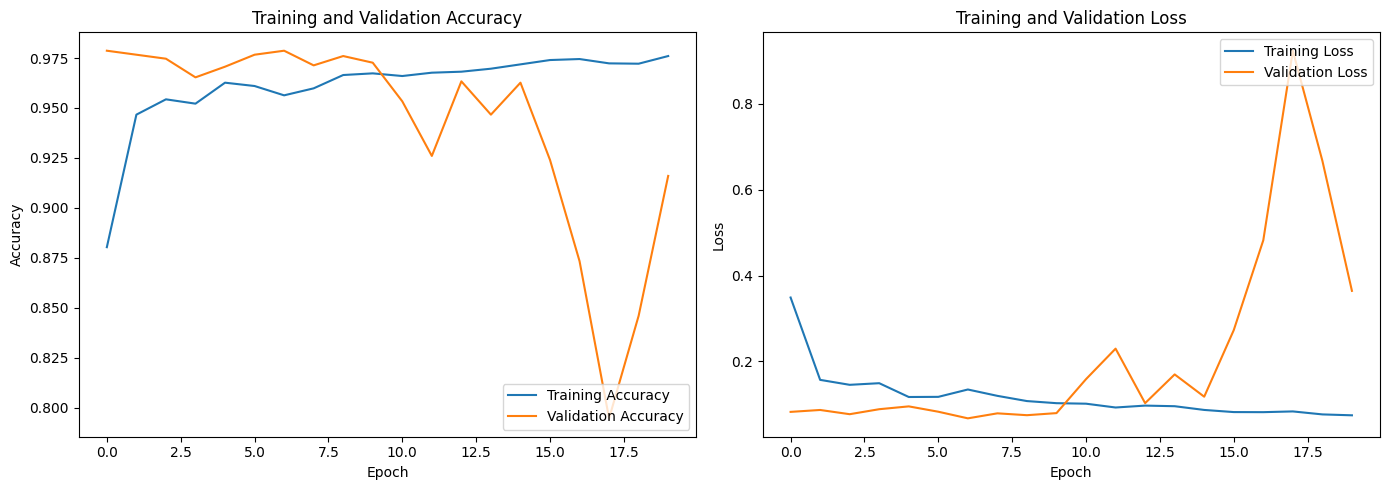

In [18]:
acc = history_simple.history['accuracy']
val_acc = history_simple.history['val_accuracy']
loss = history_simple.history['loss']
val_loss = history_simple.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

Аналіз графіків #TODO

Оцінка output моделі на валідаційних даних

In [19]:
val_loss, val_accuracy = model_simple.evaluate(val_ds)
print(f"\nCNN Accuracy: {val_accuracy*100:.2f}%")
print(f"Validation Accuracy: {val_loss:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 196ms/step - accuracy: 0.9160 - loss: 0.3645

CNN Accuracy: 91.60%
Validation Accuracy: 0.3645


Confusion Matrix для простої CNN

In [ ]:
# Отримання передбачень
y_pred = []
y_true = []

for images, labels in val_ds:
    preds = model_simple.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(f"class_names з датасету: {class_names}")
print(f"Кількість класів в class_names: {len(class_names)}")
print(f"Унікальні класи в y_true: {sorted(set(y_true))}")
print(f"Унікальні класи в y_pred: {sorted(set(y_pred))}")

# Матриця помилок
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

print("\nConfusion Matrix:")
print(cm_df)


🔍 Діагностика:
class_names з датасету: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Кількість класів в class_names: 5
Унікальні класи в y_true: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)]
Унікальні класи в y_pred: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Confusion Matrix:
           Arborio  Basmati  Ipsala  Jasmine  Karacadag
Arborio        252        0      48        0          0
Basmati          0      292       4        4          0
Ipsala           0        0     300        0          0
Jasmine          0       19       0      281          0
Karacadag       51        0       0        0        249


In [21]:
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

     Arborio       0.83      0.84      0.84       300
     Basmati       0.94      0.97      0.96       300
      Ipsala       0.85      1.00      0.92       300
     Jasmine       0.99      0.94      0.96       300
   Karacadag       1.00      0.83      0.91       300

    accuracy                           0.92      1500
   macro avg       0.92      0.92      0.92      1500
weighted avg       0.92      0.92      0.92      1500



Опис результатів з матриці та report #TODO

Transfer Learning з MobileNetV2

In [22]:
# Завантаження попередньо навченої моделі
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

C:\Users\grusevd\AppData\Local\Temp\ipykernel_29688\1304322761.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [23]:
base_model.trainable = False

In [24]:
# Побудова моделі з transfer learning
model_transfer = models.Sequential([
    # Аугментація
    augment,
    
    # Нормалізація для MobileNet
    layers.Rescaling(1./127.5, offset=-1),
    
    # Базова модель
    base_model,
    
    # Наші шари
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
], name="mobilenet_transfer")

Компіляція моделі

In [25]:
model_transfer.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_transfer.summary()

Аналіз параметрів моделі: #TODO

Модель складається з ...

Навчання моделі:

In [26]:
EPOCHS_TRANSFER = 10

history_transfer = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_TRANSFER,
    verbose=1
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 114s 585ms/step - accuracy: 0.9148 - loss: 0.2449 - val_accuracy: 0.9647 - val_loss: 0.0989
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 105s 557ms/step - accuracy: 0.9697 - loss: 0.0923 - val_accuracy: 0.9073 - val_loss: 0.2465
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 104s 552ms/step - accuracy: 0.9728 - loss: 0.0803 - val_accuracy: 0.9373 - val_loss: 0.1719
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 102s 544ms/step - accuracy: 0.9767 - loss: 0.0634 - val_accuracy: 0.9373 - val_loss: 0.1573
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 107s 571ms/step - accuracy: 0.9817 - loss: 0.0521 - val_accuracy: 0.9487 - val_loss: 0.1433
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 105s 561ms/step - accuracy: 0.9787 - loss: 0.0643 - val_accuracy: 0.9247 - val_loss: 0.2030
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 106s 562ms/step - accuracy: 0.9837 - loss: 0.0525 - val_accuracy: 0.9547 - val_loss: 0.1240
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 106s 565ms/step - accuracy: 0.9825 -

### Візуалізація результатів MobileNetV2

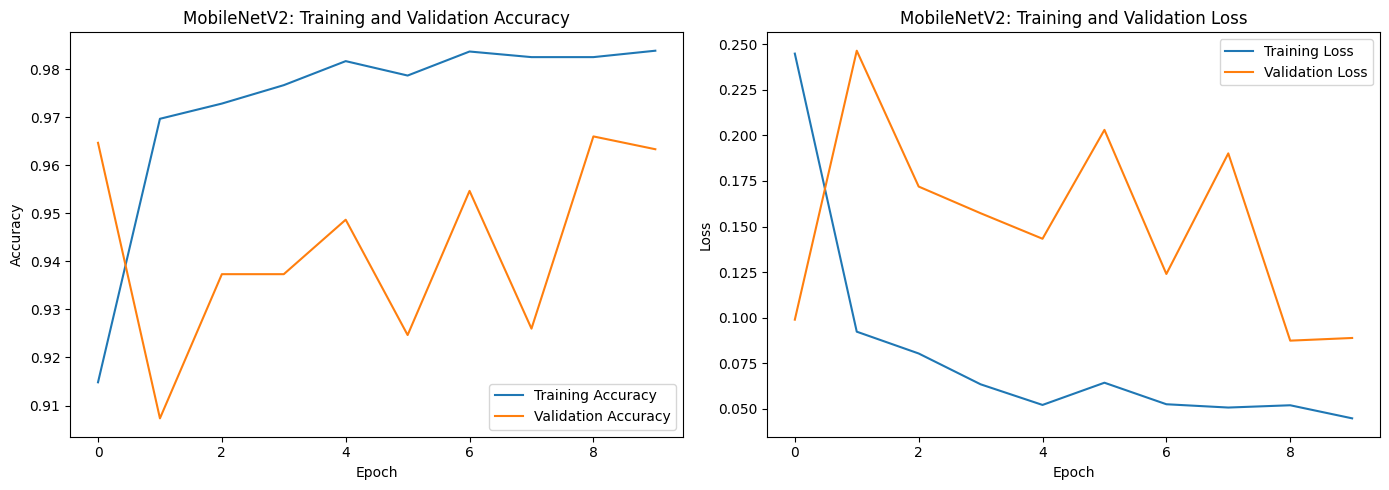

In [27]:
acc_t = history_transfer.history['accuracy']
val_acc_t = history_transfer.history['val_accuracy']
loss_t = history_transfer.history['loss']
val_loss_t = history_transfer.history['val_loss']

epochs_range_t = range(EPOCHS_TRANSFER)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range_t, acc_t, label='Training Accuracy')
plt.plot(epochs_range_t, val_acc_t, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('MobileNetV2: Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_t, loss_t, label='Training Loss')
plt.plot(epochs_range_t, val_loss_t, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('MobileNetV2: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

Оцінка output моделі MobileNetV2 на валідаційних даних 

In [28]:
val_loss_t, val_accuracy_t = model_transfer.evaluate(val_ds)
print(f"\nВалідаційна точність (MobileNetV2): {val_accuracy_t*100:.2f}%")
print(f"Валідаційна втрата (MobileNetV2): {val_loss_t:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 409ms/step - accuracy: 0.9633 - loss: 0.0889

Валідаційна точність (MobileNetV2): 96.33%
Валідаційна втрата (MobileNetV2): 0.0889


Confusion Matrix для MobileNetV2

In [29]:
# Отримання передбачень
y_pred_t = []
y_true_t = []

for images, labels in val_ds:
    preds = model_transfer.predict(images, verbose=0)
    y_pred_t.extend(np.argmax(preds, axis=1))
    y_true_t.extend(labels.numpy())

# Матриця помилок
cm_t = confusion_matrix(y_true_t, y_pred_t)
cm_df_t = pd.DataFrame(cm_t, index=class_names, columns=class_names)

print("\nConfusion Matrix (MobileNetV2):")
print(cm_df_t)


Confusion Matrix (MobileNetV2):
           Arborio  Basmati  Ipsala  Jasmine  Karacadag
Arborio        297        0       0        2          1
Basmati          0      295       1        4          0
Ipsala           0        0     300        0          0
Jasmine          1        2       0      297          0
Karacadag       44        0       0        0        256


In [30]:
# Детальний звіт класифікації
print("\nClassification Report (MobileNetV2):")
print(classification_report(y_true_t, y_pred_t, target_names=class_names))


Classification Report (MobileNetV2):
              precision    recall  f1-score   support

     Arborio       0.87      0.99      0.93       300
     Basmati       0.99      0.98      0.99       300
      Ipsala       1.00      1.00      1.00       300
     Jasmine       0.98      0.99      0.99       300
   Karacadag       1.00      0.85      0.92       300

    accuracy                           0.96      1500
   macro avg       0.97      0.96      0.96      1500
weighted avg       0.97      0.96      0.96      1500



## Порівняння моделей

In [31]:
# Порівняння точності
comparison_df = pd.DataFrame({
    'Model': ['Simple CNN', 'MobileNetV2'],
    'Validation Accuracy': [val_accuracy*100, val_accuracy_t*100],
    'Validation Loss': [val_loss, val_loss_t],
    'Training Epochs': [EPOCHS, EPOCHS_TRANSFER]
})

print("\n" + "="*60)
print("ПОРІВНЯННЯ МОДЕЛЕЙ")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)


ПОРІВНЯННЯ МОДЕЛЕЙ
      Model  Validation Accuracy  Validation Loss  Training Epochs
 Simple CNN            91.600001         0.364492               20
MobileNetV2            96.333331         0.088854               10


Висновки #TODO

- Порівняння результатів:
